In [10]:
from popsummary.popresult import PopulationResult

In [11]:
result = PopulationResult('/n/home03/newolfe/projects/tilts-and-kicks/data/inference/pixelpop/hmc/m1m2t1t2/nb40x40x10x10-var1-margsig/popsummary/test.h5')

In [12]:
import matplotlib.pyplot as plt

In [34]:
bins, rate = result.get_rates_on_grids('joint_pixelpop_rate')

bins = [ b.reshape(41, 41, 11, 11) for b in bins ]
rate = rate.reshape((1000, 40, 40, 10, 10))

In [53]:
import numpy as np
from scipy.special import logsumexp

log_dct = np.log(0.2)

only_masses = logsumexp(np.log(rate), axis=(3, 4)) + log_dct

/tmp/ipykernel_344260/1959990759.py:6: RuntimeWarning: divide by zero encountered in log
  only_masses = logsumexp(np.log(rate), axis=(3, 4)) + log_dct


In [55]:
med = np.median(only_masses, axis=0)

Text(0, 0.5, '(mass_2 / Msun)')

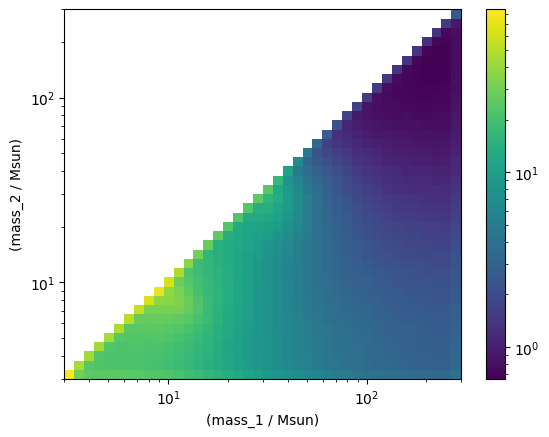

In [61]:
fig, ax = plt.subplots()
im = ax.pcolormesh(
    np.exp(bins[0][:, :, 0, 0]),
    np.exp(bins[1][:, :, 0, 0]),
    np.exp(med),
    norm='log'
)
ax.loglog();
plt.colorbar(im);

ax.set_xlabel('(mass_1 / Msun)')
ax.set_ylabel('(mass_2 / Msun)')

In [54]:
only_masses.shape

(1000, 40, 40)

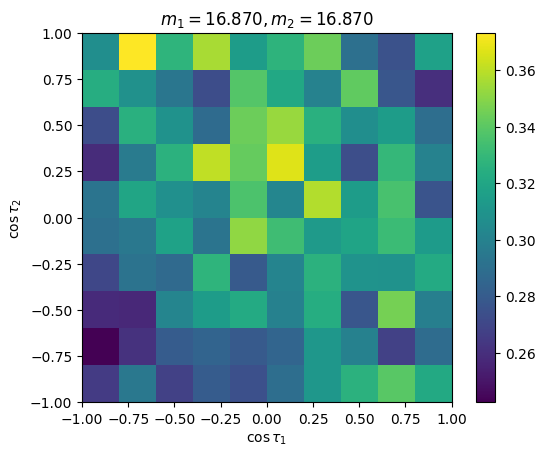

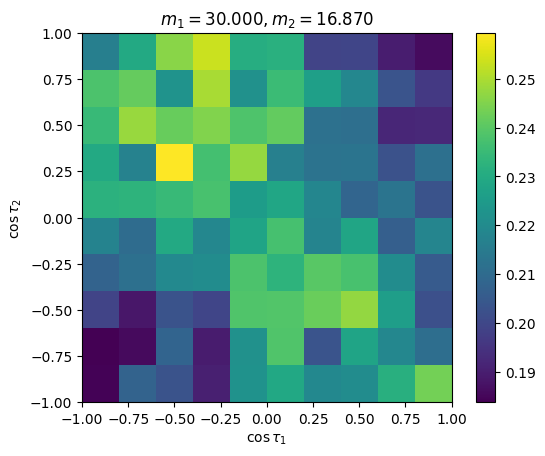

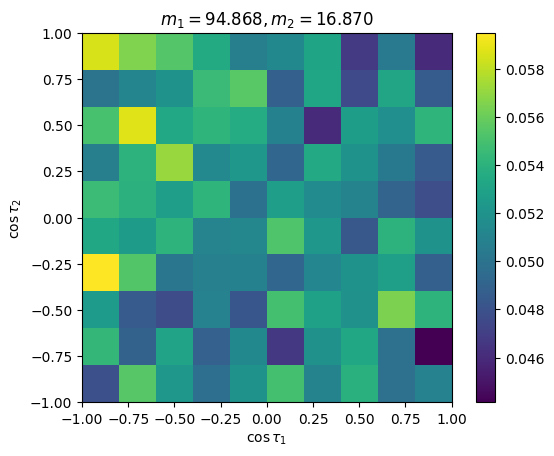

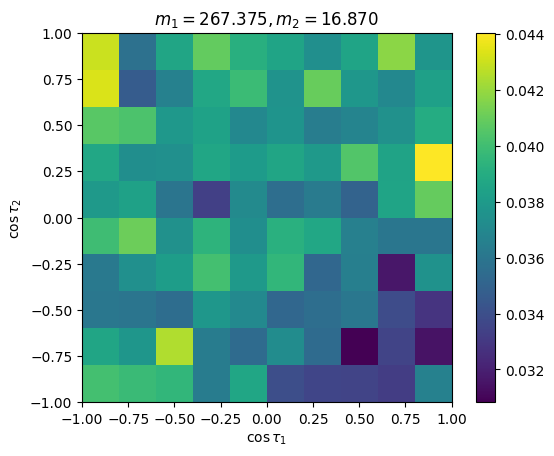

In [66]:
import numpy as np
np.exp(bins[0][11, 0, 0, 0])

#midx = 11 # ~10.6 Msun

for midx in [15, 20, 30, 39]:
    m2idx = 15

    rate_ct = rate[:, midx, m2idx]
    median_rate_ct = np.median(rate_ct, axis=0)

    fig, ax = plt.subplots()
    ax.set_title(rf'$m_1 = {np.exp(bins[0][midx,0,0,0]):.3f}, m_2 = {np.exp(bins[1][0,m2idx,0,0]):.3f}$')
    im = ax.pcolormesh(
        bins[2][midx, m2idx],
        bins[3][midx, m2idx],
        median_rate_ct
    )
    ax.set_box_aspect(1)
    ax.set_xlabel(r'$\cos \tau_1$')
    ax.set_ylabel(r'$\cos \tau_2$')
    plt.colorbar(im);

In [ ]:
# conditioning on: m1 > 45 Msun, m2 < 45 Msun
log_dlnm = np.log(bins[0][1, 0, 0, 0] - bins[0][0, 0, 0, 0])

m1_mask = bins[0][:, 0, 0, 0] > np.log(45)
m2_mask = bins[1][0, :, 0, 0] < np.log(45)

rate[:, m1_mask[:-1], m2_mask[:-1]]

IndexError: shape mismatch: indexing arrays could not be broadcast together with shapes (16,) (24,) 

In [84]:
m1_mask[:-1]

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True])

In [78]:
rate[0][m1_mask, m2_mask]

IndexError: boolean index did not match indexed array along axis 0; size of axis is 40 but size of corresponding boolean axis is 41

In [73]:
bins[0][:, 0, 0, 0]

array([1.09861229, 1.21374154, 1.3288708 , 1.44400005, 1.55912931,
       1.67425856, 1.78938782, 1.90451707, 2.01964633, 2.13477558,
       2.24990484, 2.36503409, 2.48016334, 2.5952926 , 2.71042185,
       2.82555111, 2.94068036, 3.05580962, 3.17093887, 3.28606813,
       3.40119738, 3.51632664, 3.63145589, 3.74658515, 3.8617144 ,
       3.97684365, 4.09197291, 4.20710216, 4.32223142, 4.43736067,
       4.55248993, 4.66761918, 4.78274844, 4.89787769, 5.01300695,
       5.1281362 , 5.24326546, 5.35839471, 5.47352397, 5.58865322,
       5.70378247])

In [41]:
bins[2].shape

(41, 41, 11, 11)

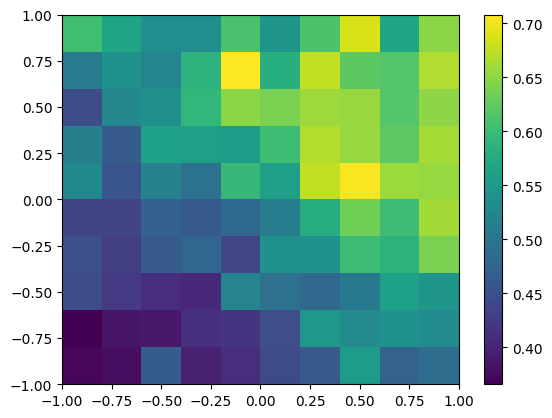

In [45]:
fig, ax = plt.subplots()
im = ax.pcolormesh(
    bins[2][midx, midx],
    bins[3][midx, midx],
    median_rate_ct
)
plt.colorbar(im);

In [39]:
median_rate_ct

array([[0.37178007, 0.36576936, 0.44453278, 0.44995278, 0.43561065,
        0.5251818 , 0.5128311 , 0.44458687, 0.507872  , 0.6026182 ],
       [0.3777379 , 0.3857247 , 0.42499936, 0.42952198, 0.43461597,
        0.455406  , 0.46328527, 0.5242698 , 0.5380094 , 0.5654615 ],
       [0.46420306, 0.38731152, 0.40963343, 0.46211943, 0.47002208,
        0.5162403 , 0.55864006, 0.53605866, 0.5216801 , 0.5321162 ],
       [0.39723969, 0.41365352, 0.40336025, 0.4780203 , 0.46241668,
        0.49495322, 0.5582559 , 0.59118617, 0.58524346, 0.53287923],
       [0.41093427, 0.41919884, 0.5196127 , 0.4373309 , 0.48179248,
        0.59527934, 0.5551738 , 0.6491351 , 0.70817155, 0.6093825 ],
       [0.44290522, 0.44683272, 0.49258286, 0.53983325, 0.50995266,
        0.55806303, 0.6001169 , 0.63908696, 0.581838  , 0.54408944],
       [0.46042466, 0.54720855, 0.47968835, 0.5400559 , 0.5794176 ,
        0.67713606, 0.66924226, 0.6580908 , 0.67608   , 0.6114676 ],
       [0.55329597, 0.52891594, 0.5047325

In [36]:
rate_ct.shape

(1000, 10, 10)